In [1]:
#   Predicting Diabetes using a Support Vector Machine Classifier 

In [2]:
#   Diabetes Data -----> Data Preprocessing -----> Train Test Split
#                                                      |
#             Support Vector Machine Classifier <______| 
#                               |
#                               |
#  New Data ----> Trained SVM Classifier -------> Diabetic or Non-Diabetic Prediction

In [ ]:
#   Importing dependencies 

import numpy as np
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn import svm

In [4]:
#   Data Collection and Analysis 
#   PIMA Diabetes Dataset

In [5]:
#   Loading the dataset 
diabetes_dataset = pd.read_csv(r"C:\Users\Emmanuel\Desktop\Dataset\diabetes.csv")

In [6]:
diabetes_dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
diabetes_dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
print(diabetes_dataset.shape)
diabetes_dataset.info()

(768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


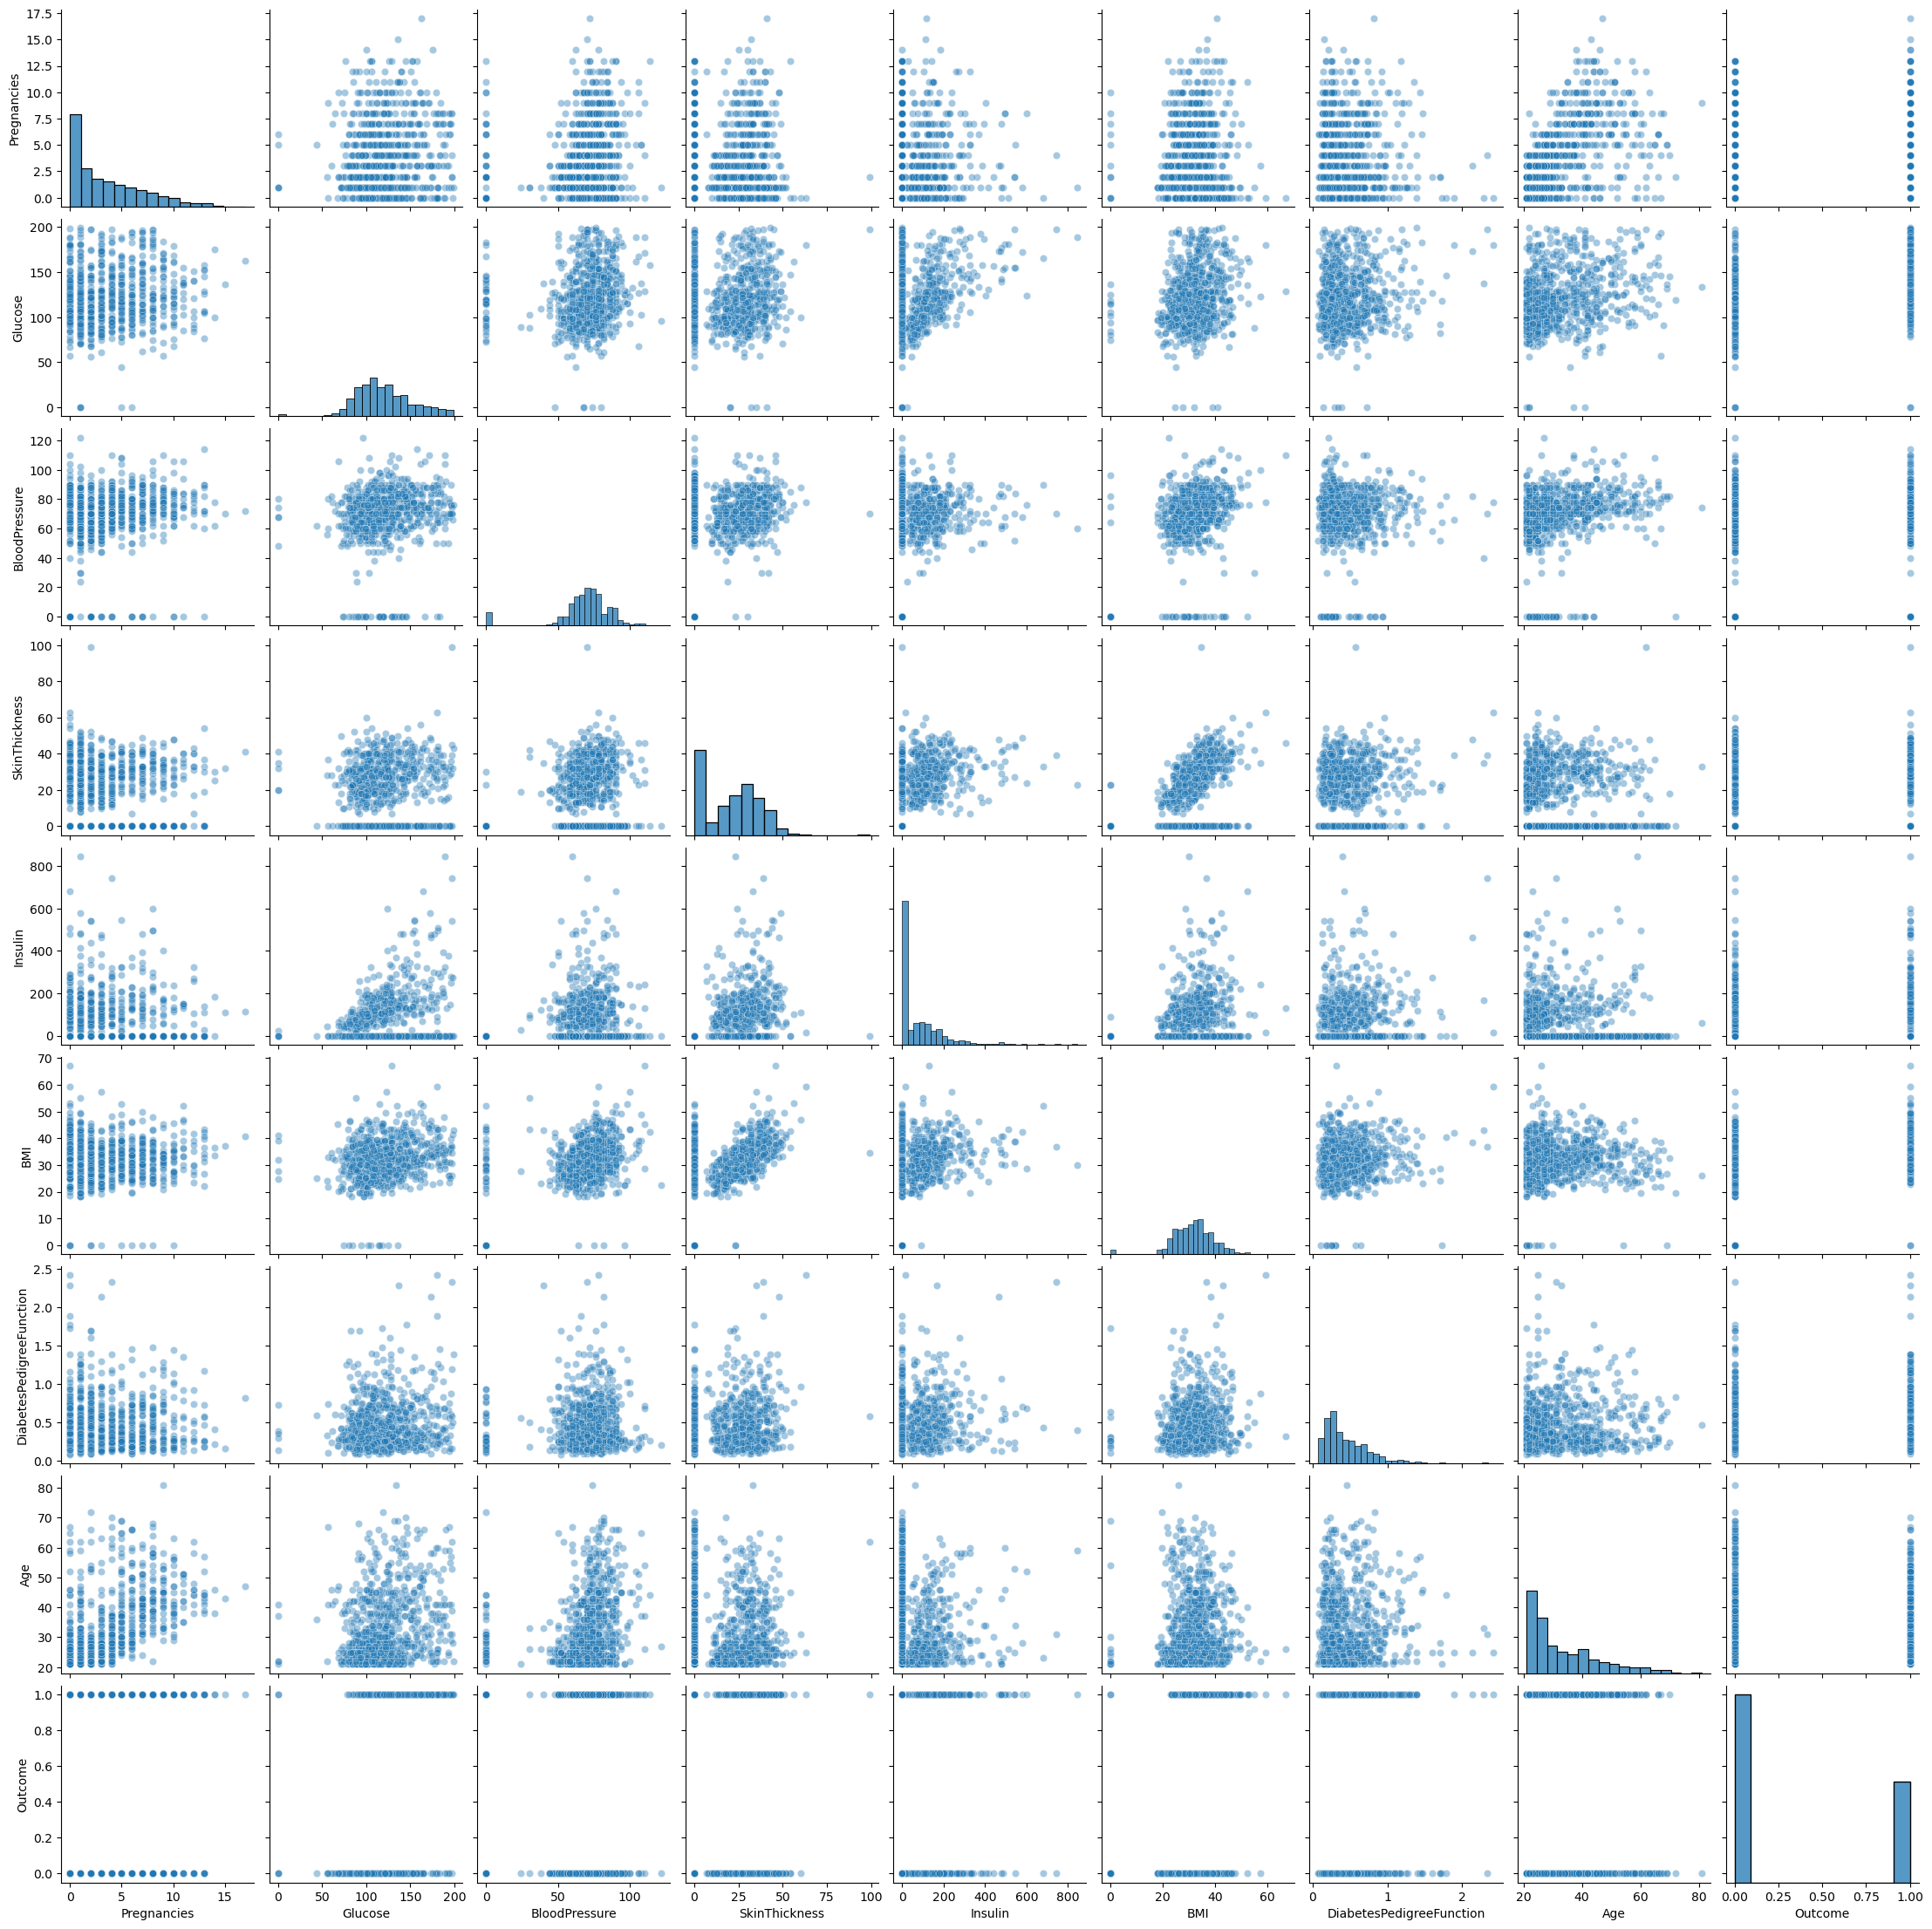

In [9]:
import seaborn as sns
sns.pairplot(diabetes_dataset, kind= 'scatter', plot_kws={'alpha': 0.4})

In [10]:
# Columns where 0 is not a real physiological value, but a disguised missing value
zero_as_missing_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Step 1: Replace 0 with NaN in those columns
diabetes_dataset[zero_as_missing_cols] = diabetes_dataset[zero_as_missing_cols].replace(0, np.nan)

# Step 2: Check how many missing values this introduced, per column
print(diabetes_dataset[zero_as_missing_cols].isnull().sum())

# Step 3: Impute missing values with the median of each column
for col in zero_as_missing_cols:
    median_value = diabetes_dataset[col].median()
    diabetes_dataset[col] = diabetes_dataset[col].fillna(median_value)

# Step 4: Confirm no missing values remain
print(diabetes_dataset[zero_as_missing_cols].isnull().sum())

# Step 5: Sanity check the new stats (min should no longer be 0 for these columns)
diabetes_dataset.describe()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [11]:
diabetes_dataset['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [12]:
#   0  -----> Non-Diabeic
#   1  -----> Diabetic

In [13]:
diabetes_dataset.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,110.682000,70.920000,27.726000,127.792000,30.885600,0.429734,31.190000
1,4.865672,142.130597,75.123134,31.686567,164.701493,35.383582,0.550500,37.067164


In [14]:
#Using IQR to check for outliers 

Q1 = diabetes_dataset.quantile(0.25, numeric_only=True)
Q3 = diabetes_dataset.quantile(0.75, numeric_only=True)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ((diabetes_dataset.select_dtypes(include='number') < lower_bound) | 
            (diabetes_dataset.select_dtypes(include='number') > upper_bound))

outlier_counts = outliers.sum()
print(outlier_counts)

Pregnancies                   4
Glucose                       0
BloodPressure                14
SkinThickness                87
Insulin                     346
BMI                           8
DiabetesPedigreeFunction     29
Age                           9
Outcome                       0
dtype: int64


In [15]:
#   Splitting data into features and target 

X = diabetes_dataset.drop(columns= 'Outcome', axis= 1)
Y = diabetes_dataset['Outcome']

In [16]:
print(X)
print(Y)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6    148.0           72.0           35.0    125.0  33.6   
1              1     85.0           66.0           29.0    125.0  26.6   
2              8    183.0           64.0           29.0    125.0  23.3   
3              1     89.0           66.0           23.0     94.0  28.1   
4              0    137.0           40.0           35.0    168.0  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10    101.0           76.0           48.0    180.0  32.9   
764            2    122.0           70.0           27.0    125.0  36.8   
765            5    121.0           72.0           23.0    112.0  26.2   
766            1    126.0           60.0           29.0    125.0  30.1   
767            1     93.0           70.0           31.0    125.0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [17]:
#   Data Standardization 

In [18]:
scaler = StandardScaler()
scaler.fit(X)
scaled_features = scaler.transform(X)
print(scaled_features)

[[ 0.63994726  0.86604475 -0.03198993 ...  0.16661938  0.46849198
   1.4259954 ]
 [-0.84488505 -1.20506583 -0.5283186  ... -0.85219976 -0.36506078
  -0.19067191]
 [ 1.23388019  2.01666174 -0.69376149 ... -1.33250021  0.60439732
  -0.10558415]
 ...
 [ 0.3429808  -0.02157407 -0.03198993 ... -0.910418   -0.68519336
  -0.27575966]
 [-0.84488505  0.14279979 -1.02464727 ... -0.34279019 -0.37110101
   1.17073215]
 [-0.84488505 -0.94206766 -0.19743282 ... -0.29912651 -0.47378505
  -0.87137393]]


In [19]:
X = scaled_features

In [20]:
#   Splitting data into training and testing 

In [21]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size= 0.2, stratify=Y, random_state= 2)

In [22]:
#   Training the model

In [23]:
Classifier = svm.SVC(kernel='linear')

In [24]:
#   training the SVM classifier

Classifier.fit(X_train, Y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [25]:
#   Model Evaluation 

In [26]:
#   Accuracy Score

#   Accuracy score on training data
X_train_prediction = Classifier.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)

print("Accuracy score of the training data : ", training_data_accuracy)

Accuracy score of the training data :  0.7801302931596091


In [27]:
#   Accuracy score on training data
X_test_prediction = Classifier.predict(X_test)
testing_data_accuracy = accuracy_score(X_test_prediction, Y_test)

print("Accuracy score of the training data : ", testing_data_accuracy)

Accuracy score of the training data :  0.7662337662337663


In [28]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(Y_test, X_test_prediction))

[[91  9]
 [27 27]]


In [29]:
from sklearn.metrics import classification_report
print(classification_report(Y_test, X_test_prediction))

              precision    recall  f1-score   support

           0       0.77      0.91      0.83       100
           1       0.75      0.50      0.60        54

    accuracy                           0.77       154
   macro avg       0.76      0.71      0.72       154
weighted avg       0.76      0.77      0.75       154



In [33]:
# Making a Predictive System

input_data = (4, 110, 92, 0, 0, 37.6, 0.191, 30)

# changing the input_data to a numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the array, as we are predicting for one instance
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

# standardize the input data
std_data = scaler.transform(input_data_reshaped)
print(std_data)

# make the prediction
prediction = Classifier.predict(std_data)
print(prediction)

if (prediction[0] == 0):
    print('The person is not diabetic')
else:
    print('The person is diabetic')

[[ 0.04601433 -0.38319655  1.62243896 -3.31319642 -1.62952723  0.74880175
  -0.84827977 -0.27575966]]
[0]
The person is not diabetic


c:\Users\Emmanuel\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
#   Trying with the RBF (Radial Basis Function) Kernel

In [30]:
Classifier_rbf = svm.SVC(kernel='rbf', class_weight='balanced')
Classifier_rbf.fit(X_train, Y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [31]:
#   Accuracy Score

#   Accuracy score on training data
X_train_prediction_rbf = Classifier_rbf.predict(X_train)
training_data_accuracy_rbf = accuracy_score(X_train_prediction_rbf, Y_train)

print("Accuracy score of the training data : ", training_data_accuracy_rbf)

Accuracy score of the training data :  0.8306188925081434


In [32]:
#   Accuracy score on testing data
X_test_prediction_rbf = Classifier_rbf.predict(X_test)
testing_data_accuracy_rbf = accuracy_score(X_test_prediction_rbf, Y_test)

print("Accuracy score of the training data : ", testing_data_accuracy_rbf)

Accuracy score of the training data :  0.6883116883116883


In [34]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(Y_test, X_test_prediction_rbf))

from sklearn.metrics import classification_report
print(classification_report(Y_test, X_test_prediction_rbf))

[[73 27]
 [21 33]]
              precision    recall  f1-score   support

           0       0.78      0.73      0.75       100
           1       0.55      0.61      0.58        54

    accuracy                           0.69       154
   macro avg       0.66      0.67      0.67       154
weighted avg       0.70      0.69      0.69       154

